# Дефектоскопия солнечных элементов по EL-снимкам
## Лестница методов: от классики до transfer learning

**Курс «Системы альтернативной энергетики». Расширенная версия.**

В прошлых занятиях мы искали неисправности ветроустановок по данным SCADA. Это были **таблицы** числовых признаков, и мы решали задачу градиентным бустингом (LightGBM).

Сегодня задача та же по смыслу — **найти неисправность** — но данные другие: это **изображения** солнечных элементов, снятые методом электролюминесценции (EL). Под напряжением исправный кремний светится равномерно, а трещины и «мёртвые» зоны выглядят тёмными и не вырабатывают энергию.

Идея этого ноутбука — не просто «обучить сеть», а **пройти лестницу методов** и на каждой ступени понять, *почему* предыдущий метод упирается в потолок и зачем нужен следующий:

1. Тривиальный baseline (всегда самый частый класс) — пол, который надо пробить.
2. Классические признаки (HOG) + LightGBM — **мостик к вашему SCADA-блоку**: превращаем картинку в таблицу и применяем уже знакомый инструмент.
3. Своя свёрточная сеть «с нуля» — сеть сама учит признаки, но на 2600 картинках ей тесно.
4. Transfer learning (ResNet18) — берём «зрение», обученное на миллионах чужих фото.
5. Дообучение (fine-tuning) — слегка подстраиваем это «зрение» под наши снимки.

А в конце разберём два вопроса, которые всегда возникают: как честно сравнивать модели и **почему для этой задачи не берут YOLO**.

## Дорожная карта

| Раздел | Что делаем | Главная мысль |
|---|---|---|
| 0–1 | Установка, загрузка данных | 2624 снимка с метками |
| 2 | Разглядываем данные | Понять, с чем работаем |
| 3–4 | Постановка задачи, деление выборки | Корректность + защита от утечки |
| 5 | Конвейер изображений | Привести картинки к виду для модели |
| 6–10 | Пять методов по нарастающей | Понять, *зачем* каждый следующий |
| 11 | Сравнение всех методов | Точность ≠ качество |
| 12 | Grad-CAM | Куда смотрит сеть (аналог SHAP) |
| 13 | Почему не YOLO | Подбор модели под задачу и разметку |
| 14 | Выводы и задания | Закрепление |

Перед запуском включите GPU: меню Colab, *Среда выполнения* — *Сменить среду выполнения* — *Аппаратный ускоритель: GPU*. Без GPU всё работает, но обучение идёт медленнее.

## 0. Подготовка среды

Ставим два пакета: датасет (картинки зашиты прямо в пакет, скачивать с GitHub ничего не нужно) и LightGBM. Остальное (PyTorch, scikit-image, scikit-learn) в Colab уже есть.

In [ ]:
!pip install -q elpv-dataset lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 MB 10.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Работаем на:", device)

Работаем на: cuda


## 1. Загрузка данных

`load_dataset()` возвращает три массива:
- `images` — картинки 300×300 в градациях серого (значения 0–255);
- `proba` — экспертная вероятность дефекта: одно из значений `0.0`, `0.33`, `0.67`, `1.0`;
- `types` — тип элемента: `mono` или `poly` (они выглядят по-разному, это пригодится при оценке).

In [ ]:
from elpv_dataset.utils import load_dataset

images, proba, types = load_dataset()
print("Всего снимков:", len(images))
print("Размер одного:", images[0].shape, "| тип чисел:", images[0].dtype)
print("Уровни вероятности дефекта:", sorted(set(proba)))
print("Типы элементов:", sorted(set(types)))

Всего снимков: 2624
Размер одного: (300, 300) | тип чисел: uint8
Уровни вероятности дефекта: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]
Типы элементов: [np.str_('mono'), np.str_('poly')]


## 2. Смотрим на данные

Перед обучением всегда смотрим на сырые данные глазами: как выглядят исправный и дефектный элемент, есть ли дисбаланс классов, чем отличаются mono и poly.

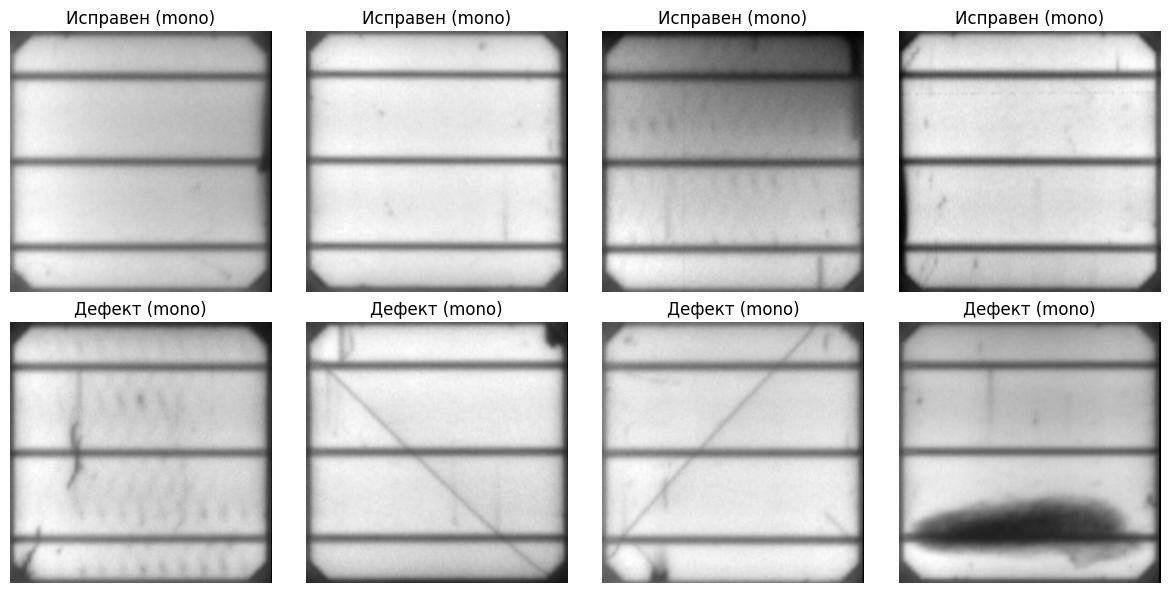

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes[0], np.where(proba == 0.0)[0][:4]):
    ax.imshow(images[i], cmap="gray"); ax.set_title(f"Исправен ({types[i]})"); ax.axis("off")
for ax, i in zip(axes[1], np.where(proba == 1.0)[0][:4]):
    ax.imshow(images[i], cmap="gray"); ax.set_title(f"Дефект ({types[i]})"); ax.axis("off")
plt.tight_layout(); plt.show()

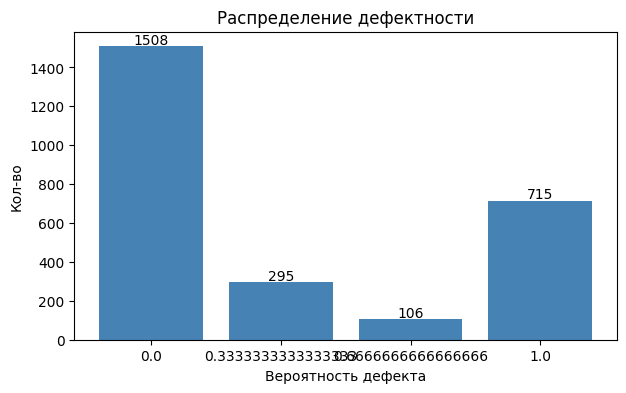

Типы: {np.str_('mono'): 1074, np.str_('poly'): 1550}


In [ ]:
levels = sorted(set(proba))
counts = [int((proba == p).sum()) for p in levels]
plt.figure(figsize=(7,4))
plt.bar([str(p) for p in levels], counts, color="steelblue")
plt.xlabel("Вероятность дефекта"); plt.ylabel("Кол-во"); plt.title("Распределение дефектности")
for i,c in enumerate(counts): plt.text(i, c+10, str(c), ha="center")
plt.show()
import collections
print("Типы:", dict(collections.Counter(types)))

## 3. Постановка задачи: из 4 уровней делаем 2 класса

Для первой задачи берём **бинарную** постановку: «исправен» или «дефект». Считаем элемент **дефектным при вероятности ≥ 0.5** (уровни `0.67` и `1.0`). Логика: эксперт склонился к «дефекту».

Это **модельное решение**, а не истина. Альтернатива — порог «> 0»: тогда классы сбалансированнее, но мы смешаем «лёгкое сомнение» с «точно сломан». В заданиях предложено сравнить оба варианта.

In [ ]:
y = (proba >= 0.5).astype(np.int64)
n_ok, n_def = int((y == 0).sum()), int((y == 1).sum())
print(f"Исправных (0): {n_ok} | Дефектных (1): {n_def} | дисбаланс ~ {n_ok/n_def:.1f}:1")

Исправных (0): 1803 | Дефектных (1): 821 | дисбаланс ~ 2.2:1


## 4. Деление выборки: train / validation / test

- **train** — на чём учимся;
- **validation** — следим за переобучением и подбираем параметры;
- **test** — трогаем один раз в конце для честной оценки.

Делим стратифицированно (сохраняем доли классов).

### Сквозная тема курса: утечка данных
Идеально делить **по модулям**: все элементы одной панели — целиком в train или целиком в test. Иначе очень похожие соседние элементы попадут и туда, и туда, и модель «подсмотрит» — метрики будут завышены. В открытой версии ELPV **нет ID модуля** (только путь, вероятность, тип), поэтому здесь мы делаем случайный стратифицированный сплит и **держим это ограничение в голове**. На реальном проекте делите по панелям.

In [ ]:
from sklearn.model_selection import train_test_split
idx = np.arange(len(images))
idx_train, idx_test = train_test_split(idx, test_size=0.20, stratify=y, random_state=SEED)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.20, stratify=y[idx_train], random_state=SEED)
print(f"train: {len(idx_train)} | val: {len(idx_val)} | test: {len(idx_test)}")
for name, ix in [("train",idx_train),("val",idx_val),("test",idx_test)]:
    print(f"  доля дефектов в {name}: {y[ix].mean():.2f}")

train: 1679 | val: 420 | test: 525
  доля дефектов в train: 0.31
  доля дефектов в val: 0.31
  доля дефектов в test: 0.31


## 5. Конвейер изображений и общие помощники

Свёрточные сети из torchvision (ResNet и т.п.) обучались на ImageNet и ждут вход строго определённого вида. Поэтому каждую картинку прогоняем через цепочку преобразований:

1. **Grayscale → 3 канала.** Сеть ждёт 3 канала (RGB), у нас 1 — копируем его трижды.
2. **Resize 224×224** — размер, под который рассчитана сеть.
3. **ToTensor** — в тензор PyTorch, пиксели в диапазон 0–1.
4. **Normalize** статистиками ImageNet — обязательно, иначе предобученные веса «не узнают» вход.

Для **train** добавляем мягкую **аугментацию** (повороты, отражение) — больше разнообразия, меньше переобучение.

Осторожно: для трещин сильные искажения опасны (могут испортить смысл дефекта), поэтому только мягкие повороты и горизонтальное отражение.

Заодно опишем универсальные функции `make_loader`, `train_model`, `predict`, чтобы не дублировать код для разных моделей.

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# для ResNet (3 канала, 224)
train_tf = transforms.Compose([
    transforms.ToPILImage(), transforms.Grayscale(3), transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(), transforms.RandomRotation(10),
    transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std)])
eval_tf = transforms.Compose([
    transforms.ToPILImage(), transforms.Grayscale(3), transforms.Resize((224,224)),
    transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std)])

class ELPVDataset(Dataset):
    def __init__(self, X, y, tf): self.X, self.y, self.tf = X, y, tf
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.tf(self.X[i]), self.y[i]

def make_loader(indices, tf, shuffle):
    ds = ELPVDataset(images[indices], y[indices], tf)
    return DataLoader(ds, batch_size=32, shuffle=shuffle, num_workers=2)

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    hist = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    for ep in range(1, epochs+1):
        for phase, loader, train_mode in [("train",train_loader,True),("val",val_loader,False)]:
            model.train() if train_mode else model.eval()
            torch.set_grad_enabled(train_mode)
            L=c=n=0
            for xb,yb in loader:
                xb,yb=xb.to(device),yb.to(device)
                if train_mode: optimizer.zero_grad()
                out=model(xb); loss=criterion(out,yb)
                if train_mode: loss.backward(); optimizer.step()
                L+=loss.item()*len(yb); c+=(out.argmax(1)==yb).sum().item(); n+=len(yb)
            hist[f"{phase}_loss"].append(L/n); hist[f"{phase}_acc"].append(c/n)
        print(f"эпоха {ep}/{epochs} | train acc {hist['train_acc'][-1]:.3f} | val acc {hist['val_acc'][-1]:.3f}")
    return hist

def predict(model, loader):
    model.eval(); torch.set_grad_enabled(False); preds=[]
    for xb,_ in loader: preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

# сюда каждый метод будет складывать результаты для финального сравнения
from sklearn.metrics import accuracy_score, f1_score
results = {}
def record(name, y_true, y_pred):
    acc=accuracy_score(y_true,y_pred); f1=f1_score(y_true,y_pred,average="macro")
    results[name]={"acc":acc,"f1":f1}
    print(f"[{name}] accuracy={acc:.3f} | macro-F1={f1:.3f}")
print("Помощники готовы.")

Помощники готовы.


## Лестница методов

Дальше пять ступеней. После каждой смотрите на строчку с accuracy и macro-F1 — в конце мы сведём их в одну картинку и увидим прогресс.

### Метод 1. Тривиальный baseline

Самый «глупый» вариант: всегда отвечать самым частым классом («исправен»). Любая осмысленная модель обязана его побеждать. Это наша точка отсчёта.

In [ ]:
majority = np.bincount(y[idx_train]).argmax()
pred_major = np.full(len(idx_test), majority)
record("1. Majority baseline", y[idx_test], pred_major)

[1. Majority baseline] accuracy=0.688 | macro-F1=0.407


### Метод 2. Классические признаки (HOG) + LightGBM

Это прямой мостик к вашему SCADA-блоку. Идея: **превратить картинку в таблицу чисел** и применить уже знакомый LightGBM.

Как делаем признаки — через **HOG (Histogram of Oriented Gradients)**. Интуиция: картинку режут на маленькие клетки, в каждой считают, в какую сторону направлены перепады яркости (градиенты) и насколько они сильны. Трещина — это резкий перепад яркости определённого направления, поэтому HOG хорошо её «чувствует». На выходе каждая картинка превращается в вектор фиксированной длины — обычную строку таблицы.

Важный вывод этой ступени: такой подход работает, но потолок у него невысокий. Признаки придумал человек (HOG), и они не знают ничего конкретно про дефекты солнечных элементов. Это мотивирует перейти к моделям, которые **сами учат признаки** — к свёрточным сетям.

In [ ]:
from skimage.feature import hog
from skimage.transform import resize as skresize
import lightgbm as lgb

def hog_features(img):
    g = skresize(img, (128,128), anti_aliasing=True)
    return hog(g, orientations=9, pixels_per_cell=(16,16),
               cells_per_block=(2,2), feature_vector=True)

print("Считаем HOG-признаки (это превращает картинки в таблицу)...")
X_train_hog = np.stack([hog_features(images[i]) for i in idx_train])
X_test_hog  = np.stack([hog_features(images[i]) for i in idx_test])
print("Размер таблицы признаков:", X_train_hog.shape, "(строки = картинки, столбцы = признаки)")

lgbm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                          class_weight="balanced", verbose=-1)
lgbm.fit(X_train_hog, y[idx_train])
record("2. HOG + LightGBM", y[idx_test], lgbm.predict(X_test_hog))

Считаем HOG-признаки (это превращает картинки в таблицу)...
Размер таблицы признаков: (1679, 1764) (строки = картинки, столбцы = признаки)
[2. HOG + LightGBM] accuracy=0.813 | macro-F1=0.767


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Метод 3. Своя свёрточная сеть «с нуля»

Теперь пусть модель **сама** придумает признаки. В этом суть свёрточной сети.

Что такое свёртка простыми словами: по картинке скользит маленькое окно-фильтр (например 3×3) и в каждой позиции считает «насколько здесь есть искомый узор» — край, угол, пятно. Ранние слои ловят простые узоры (границы), следующие собирают из них более сложные (текстуры, формы). Никто не задаёт эти фильтры руками — сеть подбирает их сама в ходе обучения.

Проблема: у нас всего около 1700 обучающих картинок. Это **мало**, чтобы сеть с нуля выучила хорошие фильтры — она склонна **переобучаться** (запоминать обучающую выборку вместо обобщения). Смотрите на разрыв между train acc и val acc: если train сильно выше val — это и есть переобучение. Эта ступень показывает, *почему* в следующем методе мы не учим зрение с нуля, а заимствуем его.

In [ ]:
# лёгкий конвейер: 1 канал, 96x96 (своей маленькой сети большой вход не нужен)
small_train_tf = transforms.Compose([
    transforms.ToPILImage(), transforms.Grayscale(1), transforms.Resize((96,96)),
    transforms.RandomHorizontalFlip(), transforms.ToTensor()])
small_eval_tf = transforms.Compose([
    transforms.ToPILImage(), transforms.Grayscale(1), transforms.Resize((96,96)),
    transforms.ToTensor()])

small_train_loader = DataLoader(ELPVDataset(images[idx_train], y[idx_train], small_train_tf), batch_size=32, shuffle=True,  num_workers=2)
small_val_loader   = DataLoader(ELPVDataset(images[idx_val],   y[idx_val],   small_eval_tf),  batch_size=32, shuffle=False, num_workers=2)
small_test_loader  = DataLoader(ELPVDataset(images[idx_test],  y[idx_test],  small_eval_tf),  batch_size=32, shuffle=False, num_workers=2)

small_cnn = nn.Sequential(
    nn.Conv2d(1,16,3,padding=1),  nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
    nn.Flatten(), nn.Linear(64,2)).to(device)

cw = np.bincount(y[idx_train]); class_weights = torch.tensor(cw.sum()/cw, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(small_cnn.parameters(), lr=1e-3)

train_model(small_cnn, small_train_loader, small_val_loader, optimizer, criterion, epochs=8)
record("3. CNN с нуля", y[idx_test], predict(small_cnn, small_test_loader))

эпоха 1/8 | train acc 0.660 | val acc 0.752
эпоха 2/8 | train acc 0.684 | val acc 0.757
эпоха 3/8 | train acc 0.730 | val acc 0.750
эпоха 4/8 | train acc 0.739 | val acc 0.755
эпоха 5/8 | train acc 0.744 | val acc 0.702
эпоха 6/8 | train acc 0.747 | val acc 0.743
эпоха 7/8 | train acc 0.728 | val acc 0.752
эпоха 8/8 | train acc 0.742 | val acc 0.752
[3. CNN с нуля] accuracy=0.756 | macro-F1=0.719


### Метод 4. Transfer learning (ResNet18)

Главная идея: взять сеть ResNet18, уже обученную на миллионах фотографий ImageNet. Её ранние слои умеют находить универсальные вещи — края, текстуры, контуры. Эти навыки прекрасно подходят и для поиска трещин, хотя ImageNet никогда не видел солнечных элементов.

Что делаем:
1. Загружаем ResNet18 **с предобученными весами**.
2. **Замораживаем** все слои (`requires_grad = False`) — они уже умные, их не трогаем.
3. Меняем только последний слой (`fc`, «голову») на свой, с 2 выходами. Обучаем **только его**.

Так мы обучаем буквально пару тысяч параметров вместо миллионов, и поэтому маленького датасета хватает.

In [ ]:
tl = make_loader(idx_train, train_tf, True)
vl = make_loader(idx_val,   eval_tf,  False)
test_loader = make_loader(idx_test, eval_tf, False)

resnet = models.resnet18(weights="IMAGENET1K_V1")
for p in resnet.parameters(): p.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)
print("Обучаемых параметров:", sum(p.numel() for p in resnet.parameters() if p.requires_grad))

hist = train_model(resnet, tl, vl, optimizer, criterion, epochs=8)
record("4. Transfer learning (frozen)", y[idx_test], predict(resnet, test_loader))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Обучаемых параметров: 1026
эпоха 1/8 | train acc 0.603 | val acc 0.776
эпоха 2/8 | train acc 0.677 | val acc 0.769
эпоха 3/8 | train acc 0.733 | val acc 0.714
эпоха 4/8 | train acc 0.735 | val acc 0.776
эпоха 5/8 | train acc 0.752 | val acc 0.800
эпоха 6/8 | train acc 0.742 | val acc 0.781
эпоха 7/8 | train acc 0.755 | val acc 0.667
эпоха 8/8 | train acc 0.770 | val acc 0.750
[4. Transfer learning (frozen)] accuracy=0.789 | macro-F1=0.770


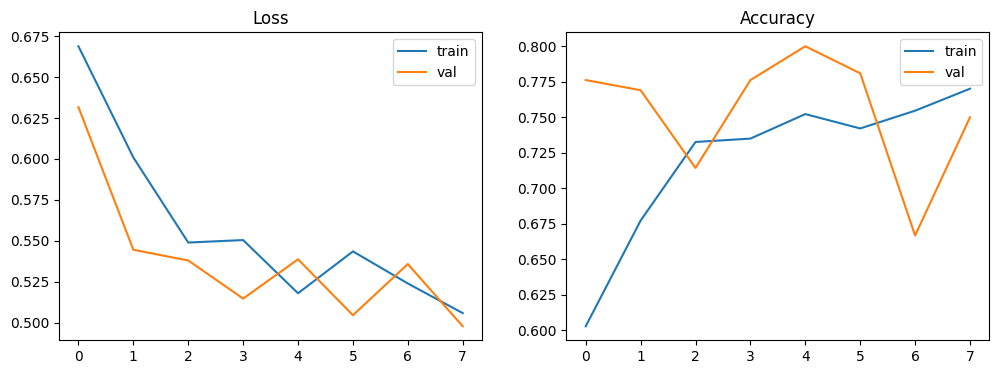

In [ ]:
# кривые обучения transfer learning
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
a1.plot(hist["train_loss"],label="train"); a1.plot(hist["val_loss"],label="val"); a1.set_title("Loss"); a1.legend()
a2.plot(hist["train_acc"],label="train"); a2.plot(hist["val_acc"],label="val"); a2.set_title("Accuracy"); a2.legend()
plt.show()

### Метод 5. Дообучение (fine-tuning)

Теперь «разморозим» последний свёрточный блок ResNet (`layer4`) и дообучим его **с очень маленьким шагом обучения**. Так сеть слегка подстроит и свои «глаза» под особенности EL-снимков. Маленький learning rate критичен: большой шаг разрушил бы полезные веса, выученные на ImageNet.

In [ ]:
for p in resnet.layer4.parameters(): p.requires_grad = True
optimizer = torch.optim.Adam([p for p in resnet.parameters() if p.requires_grad], lr=1e-5)
train_model(resnet, tl, vl, optimizer, criterion, epochs=4)
record("5. Fine-tuning (layer4)", y[idx_test], predict(resnet, test_loader))

эпоха 1/4 | train acc 0.766 | val acc 0.757
эпоха 2/4 | train acc 0.774 | val acc 0.760
эпоха 3/4 | train acc 0.777 | val acc 0.757
эпоха 4/4 | train acc 0.792 | val acc 0.764
[5. Fine-tuning (layer4)] accuracy=0.815 | macro-F1=0.799


## 11. Сравнение всех методов

Сводим accuracy и macro-F1 в одну картинку. Обычно видно лестницу: тривиальный baseline внизу, HOG+LightGBM выше, CNN с нуля примерно там же или чуть лучше, а transfer learning и fine-tuning заметно впереди. Точные числа от запуска к запуску немного гуляют, но порядок устойчив.

Почему смотрим не только на accuracy: при дисбалансе классов высокая точность может означать «угадал большинство, но прозевал дефекты». Macro-F1 усредняет качество по обоим классам и честнее показывает, ловим ли мы дефекты.

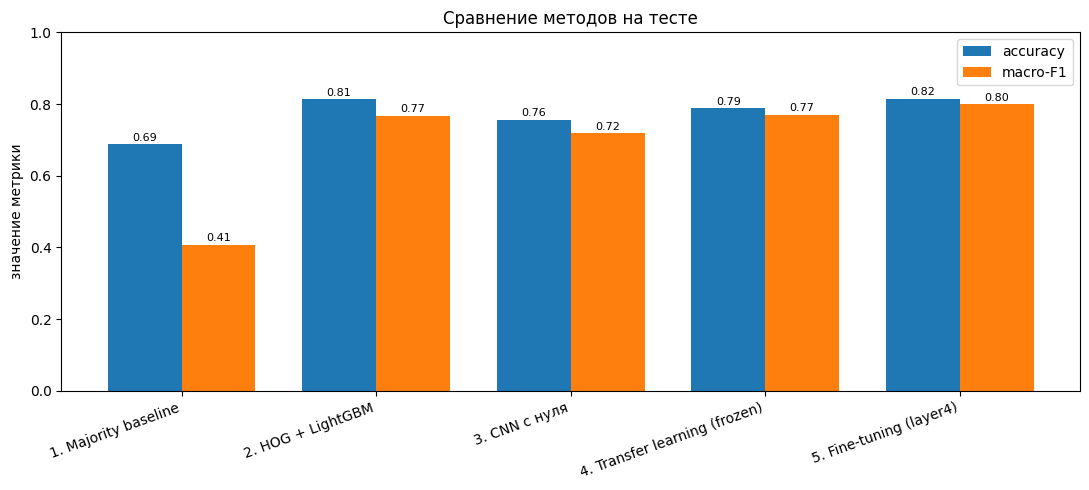

In [ ]:
names = list(results.keys())
accs = [results[n]["acc"] for n in names]
f1s  = [results[n]["f1"]  for n in names]
xpos = np.arange(len(names)); w=0.38
plt.figure(figsize=(11,5))
plt.bar(xpos-w/2, accs, w, label="accuracy")
plt.bar(xpos+w/2, f1s,  w, label="macro-F1")
plt.xticks(xpos, names, rotation=20, ha="right")
plt.ylim(0,1); plt.ylabel("значение метрики"); plt.title("Сравнение методов на тесте"); plt.legend()
for i,(a,f) in enumerate(zip(accs,f1s)):
    plt.text(i-w/2,a+0.01,f"{a:.2f}",ha="center",fontsize=8)
    plt.text(i+w/2,f+0.01,f"{f:.2f}",ha="center",fontsize=8)
plt.tight_layout(); plt.show()

## 12. Глубокая оценка лучшей модели

Берём дообученную ResNet и смотрим подробно: матрицу ошибок, precision/recall/F1 и, отдельно, качество на mono и poly. Особенно важен **recall дефектов** — какую долю реальных дефектов мы поймали (пропустить дефект дорого).

              precision    recall  f1-score   support

    исправен      0.920     0.801     0.856       361
      дефект      0.659     0.848     0.741       164

    accuracy                          0.815       525
   macro avg      0.790     0.824     0.799       525
weighted avg      0.839     0.815     0.820       525



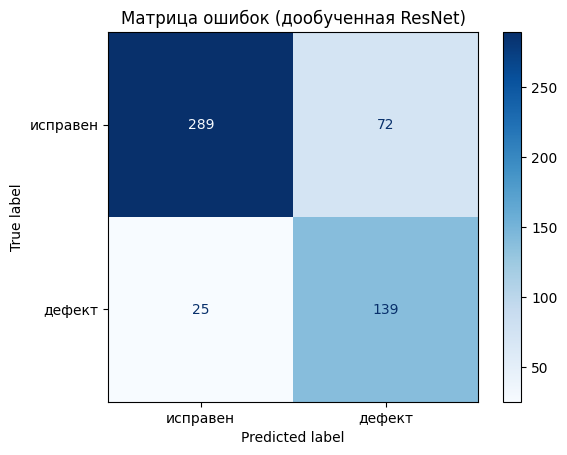

Точность по типам:
  mono: 0.818  (в тесте: 220)
  poly: 0.813  (в тесте: 305)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
final_pred = predict(resnet, test_loader)
y_true = y[idx_test]
print(classification_report(y_true, final_pred, target_names=["исправен","дефект"], digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_true, final_pred), display_labels=["исправен","дефект"]).plot(cmap="Blues")
plt.title("Матрица ошибок (дообученная ResNet)"); plt.show()

tt = types[idx_test]
print("Точность по типам:")
for t in ["mono","poly"]:
    m = tt==t
    print(f"  {t}: {(final_pred[m]==y_true[m]).mean():.3f}  (в тесте: {m.sum()})")

## 13. Grad-CAM: куда смотрит сеть (аналог SHAP)

Для SCADA мы объясняли решения через SHAP. Для картинок аналог — **Grad-CAM**: он подсвечивает области изображения, на которые сеть опиралась. Если красные зоны совпадают с трещинами — модели можно доверять; если она смотрит на фон или края — это тревожный сигнал.

Технически: берём активации последнего свёрточного слоя, взвешиваем их по градиентам нужного класса и получаем «тепловую карту важности».

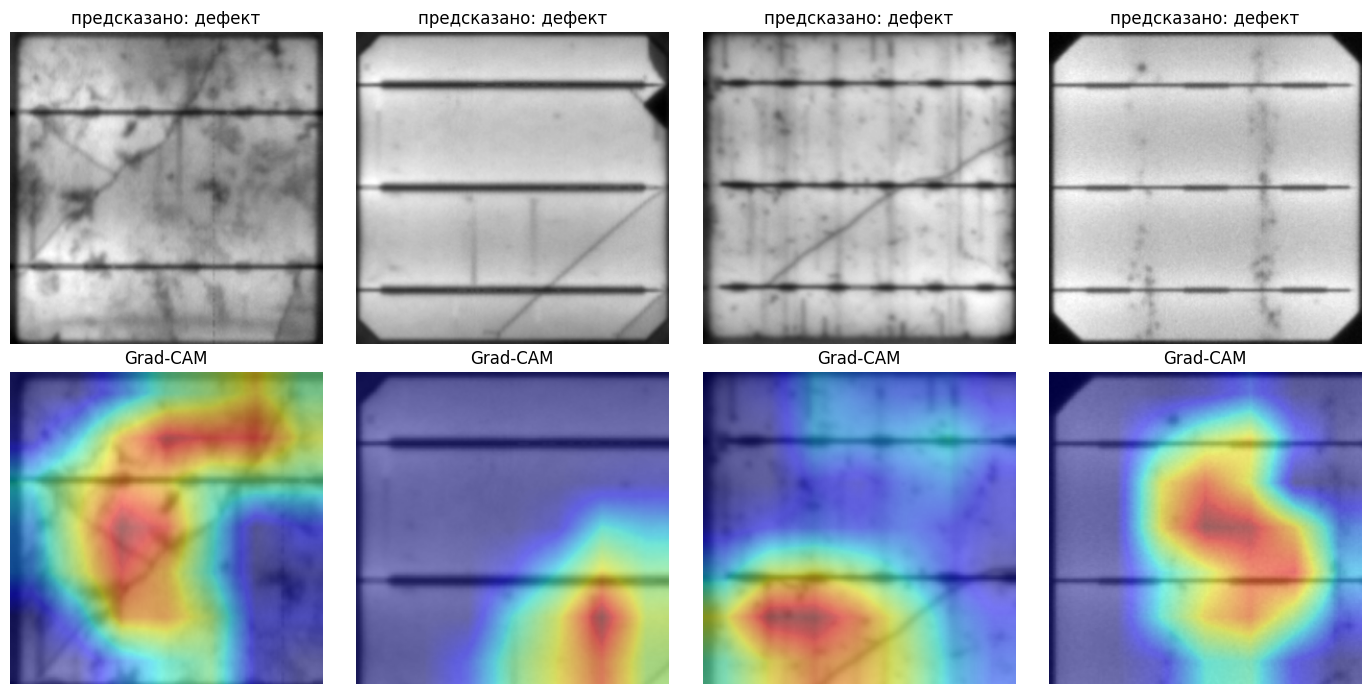

In [ ]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model=model; self.acts=None; self.grads=None
        target_layer.register_forward_hook(self._a)
        target_layer.register_full_backward_hook(self._g)
    def _a(self,m,i,o): self.acts=o.detach()
    def _g(self,m,gi,go): self.grads=go[0].detach()
    def heatmap(self, x, cls):
        x = x.clone().requires_grad_(True)  # вход должен требовать градиент,
                                            # иначе при замороженном backbone карта не построится
        self.model.zero_grad()
        out = self.model(x); out[0, cls].backward()
        w = self.grads.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam[0,0].detach().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8)

gradcam = GradCAM(resnet, resnet.layer4[-1])
defect_idx = idx_test[y[idx_test]==1][:4]
fig, axes = plt.subplots(2,4,figsize=(14,7))
torch.set_grad_enabled(True); resnet.eval()
for col, gi in enumerate(defect_idx):
    x = eval_tf(images[gi]).unsqueeze(0).to(device)
    pred = resnet(x).argmax(1).item()
    cam = gradcam.heatmap(x, cls=1)
    axes[0,col].imshow(images[gi], cmap="gray"); axes[0,col].axis("off")
    axes[0,col].set_title("предсказано: " + ("дефект" if pred==1 else "исправен"))
    axes[1,col].imshow(images[gi], cmap="gray"); axes[1,col].imshow(cam, cmap="jet", alpha=0.5)
    axes[1,col].axis("off"); axes[1,col].set_title("Grad-CAM")
plt.tight_layout(); plt.show()

## 14. Почему не YOLO?

Очень частый вопрос: «есть же YOLO, почему не взять её?» Разберём честно, потому что это учит главному принципу — **модель выбирают под задачу И под имеющуюся разметку**.

### Чем вообще занимается YOLO
YOLO (You Only Look Once) — это семейство моделей для **детекции в реальном времени**: она отвечает не только «что на картинке», но и «**где** именно», обводя объекты рамками (bounding boxes), а в режиме сегментации — масками. Семейство быстро развивается: YOLOv8 (2023), затем YOLO11 (2024), YOLO12 (2025), а самая свежая на январь 2026 — YOLO26 (NMS-free, оптимизирована под edge-устройства). Все они умеют детекцию, сегментацию, классификацию, оценку позы и ориентированные рамки.

### Почему для нашей задачи она избыточна
Наша задача — **классификация целой картинки**: один уже вырезанный элемент → одна метка «исправен/дефект». В датасете ELPV нет ни рамок, ни масок — только метка на весь элемент. А сила YOLO — именно в локализации «где объект». Если у нас нет разметки «где дефект», то использовать детектор не на чем: его главное умение простаивает.

Формально у YOLO есть и режим чистой классификации (`yolo*-cls`), так что технически её применить можно. Но:
- её классификационный backbone — это та же свёрточная сеть, предобученная на ImageNet, то есть концептуально это **тот же transfer learning**, что мы уже сделали, только внутри более тяжёлого фреймворка;
- мы не используем ни детекцию, ни сегментацию — то, ради чего YOLO и берут;
- для небольшого набора чёрно-белых картинок ResNet/EfficientNet из torchvision проще, прозрачнее для учёбы (видно каждый шаг) и имеет богатый инструментарий объяснимости (тот же Grad-CAM).

### Когда YOLO была бы правильным выбором
Если бы у нас были EL-снимки **целых модулей** и стояла задача **найти и обвести** каждый дефект, да ещё классифицировать тип дефекта по месту — это уже детекция или сегментация, и вот тогда YOLO (или YOLO26/YOLO11) — отличный инструмент. Но для этого нужна **разметка рамками или масками**, которой у нас нет. ELPV отдаёт уже вырезанные отдельные элементы с одной меткой на каждый — то есть задача локализации снята за нас, и остаётся чистая классификация.

Главный вывод: детектор без разметки «где» — это инструмент не под ту задачу. Сначала смотрим, **какая разметка есть** и **какой вопрос задаём**, и только потом выбираем модель.

In [ ]:
# Иллюстрация (НЕ запускаем) — как выглядел бы YOLO в режиме классификации.
# Это нужно только чтобы показать API; для нашей задачи мы остаёмся на ResNet.
#
# !pip install ultralytics
# from ultralytics import YOLO
# model = YOLO("yolo11n-cls.pt")          # классификационная версия
# # требует структуру папок dataset/train/<класс>/*.png и dataset/val/<класс>/*.png
# model.train(data="dataset", epochs=10, imgsz=224)
#
# Минусы для нашего случая: тяжелее зависимость, менее прозрачно для учебных целей,
# и никакого выигрыша над transfer learning, т.к. локализация (сила YOLO) нам не нужна.
print("YOLO здесь не нужна: у нас классификация вырезанных элементов, а не детекция дефектов на модуле.")

YOLO здесь не нужна: у нас классификация вырезанных элементов, а не детекция дефектов на модуле.


## 15. Что мы поняли и задания

Главные мысли:
- **Тип данных и разметка определяют метод.** Та же по смыслу задача «найти дефект», но картинки требуют других инструментов, чем таблицы SCADA, а отсутствие рамок исключает детекторы вроде YOLO.
- **Лестница методов.** Hand-crafted признаки (HOG) + LightGBM работают, но упираются в потолок; CNN с нуля переобучается на малых данных; transfer learning заимствует «зрение» и побеждает; fine-tuning добавляет ещё немного.
- **Точность ≠ качество.** При дисбалансе смотрим на macro-F1, recall дефектов и на mono/poly отдельно.
- **Объяснимость обязательна.** Grad-CAM (как SHAP в SCADA) показывает, что сеть смотрит на трещины.
- **Утечка данных** — сквозная тема: в идеале делим по модулям.

### Задания
1. **Порог бинаризации.** Переделайте метку на «дефект = proba > 0» и сравните recall дефектов. Что изменилось и почему?
2. **Другой backbone.** Замените `resnet18` на `mobilenet_v3_small` или `efficientnet_b0`. Как меняются скорость и качество?
3. **Сильнее аугментация.** Добавьте `RandomResizedCrop`. Стало лучше или хуже и почему для трещин это рискованно?
4. **Три класса.** Соберите задачу «исправен / лёгкий дефект / сильный дефект» и постройте матрицу ошибок 3×3.
5. **HOG vs CNN-признаки.** Достаньте из обученной ResNet вектор перед последним слоем (эмбеддинг) и обучите на нём LightGBM. Сравните с HOG+LightGBM. Какой набор признаков сильнее и почему?
6. **YOLO на практике.** Возьмите датасет EL-снимков целых модулей с рамками (если найдёте) и сравните постановку «детекция через YOLO» с нашей «классификация вырезанных элементов».